Para esta actividad se ha creado un archivo usuarios_win_mac_lin.csv con datos de entrada a modo de ejemplo para clasificar si el usuario que visita un sitio web usa como sistema operativo Windows, Macintosh o Linux.

Nuestra información de entrada son 4 características que se tomó de una web que utiliza Google Analytics y son:

●      Duración de la visita en Segundos

●      Cantidad de Páginas Vistas durante la Sesión

●      Cantidad de Acciones del usuario (click, scroll, uso de checkbox, sliders,etc)

●      Suma del Valor de las acciones (cada acción lleva asociada una valoración de importancia)

Como la salida es discreta, asignaremos los siguientes valores a las etiquetas:

0 – Windows

1 – Macintosh

2 -Linux

Tu tarea es crear una Jupyter Notebook Regresion_logistica.ipynb que permita predecir qué sistema operativo utiliza un usuario según los datos de entrada.

In [1]:
import numpy as np
import pandas as pd
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)


## 2. Cargar y explorar los datos

In [2]:
# Cargamos el dataset
df = pd.read_csv(r'C:\Users\usuario\OneDrive\Desktop\3! Cuatrimestre\03 - Aprendizaje Automático\01 - Ejercicios Entrega\Semana 4\usuarios_win_mac_lin.csv')

print('Primeras filas del dataset:')
df.head(10)

Primeras filas del dataset:


,duracion_segundos,paginas_vistas,cantidad_acciones,valor_acciones,sistema_operativo
0,245,5,12,34,0
1,310,8,20,55,0
2,180,3,8,22,0
3,420,10,25,70,0
4,95,2,5,10,0
5,500,12,30,85,0
6,150,4,9,28,0
7,380,9,22,60,0
8,270,6,15,40,0
9,340,7,18,50,0


In [3]:
# Información general del dataset
print('Forma del dataset:', df.shape)
print('\nInformación general:')
df.info()

Forma del dataset: (45, 5)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   duracion_segundos  45 non-null     int64
 1   paginas_vistas     45 non-null     int64
 2   cantidad_acciones  45 non-null     int64
 3   valor_acciones     45 non-null     int64
 4   sistema_operativo  45 non-null     int64
dtypes: int64(5)
memory usage: 1.9 KB


In [4]:
# Estadísticas descriptivas
print('Estadísticas descriptivas:')
df.describe()

Estadísticas descriptivas:


,duracion_segundos,paginas_vistas,cantidad_acciones,valor_acciones,sistema_operativo
count,45.000000,45.000000,45.000000,45.000000,45.000000
mean,372.111111,8.044444,23.533333,55.666667,1.000000
std,300.564788,6.138387,16.660514,35.510562,0.825723
min,35.000000,1.000000,5.000000,8.000000,0.000000
25%,95.000000,2.000000,11.000000,25.000000,0.000000
50%,290.000000,7.000000,17.000000,48.000000,1.000000
75%,640.000000,13.000000,30.000000,85.000000,2.000000
max,950.000000,20.000000,65.000000,130.000000,2.000000


In [5]:
# Distribución de sistemas operativos
etiquetas = {0: 'Windows', 1: 'Macintosh', 2: 'Linux'}
conteo = df['sistema_operativo'].value_counts().rename(etiquetas)
print('Distribución de sistemas operativos:')
print(conteo)

Distribución de sistemas operativos:
sistema_operativo
Windows      15
Macintosh    15
Linux        15
Name: count, dtype: int64


## 3. Preparar los datos para el modelo

In [6]:
# Separamos las características (X) de las etiquetas (Y)
X = df[['duracion_segundos', 'paginas_vistas', 'cantidad_acciones', 'valor_acciones']].values
Y = df['sistema_operativo'].values

print('Forma de X (características):', X.shape)
print('Forma de Y (etiquetas):', Y.shape)
print('\nPrimeros 5 valores de X:')
print(X[:5])
print('\nPrimeros 5 valores de Y:')
print(Y[:5])

Forma de X (características): (45, 4)
Forma de Y (etiquetas): (45,)

Primeros 5 valores de X:
[[245   5  12  34]
 [310   8  20  55]
 [180   3   8  22]
 [420  10  25  70]
 [ 95   2   5  10]]

Primeros 5 valores de Y:
[0 0 0 0 0]


In [7]:
# Dividimos en datos de entrenamiento (80%) y de prueba (20%)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print('Datos de entrenamiento:', X_train.shape)
print('Datos de prueba:       ', X_test.shape)

Datos de entrenamiento: (36, 4)
Datos de prueba:        (9, 4)


## 4. Crear y entrenar el modelo

In [8]:
# Creamos el clasificador de Regresión Logística
clasificador = LogisticRegression(max_iter=1000, random_state=42)

# Entrenamos el modelo con los datos de entrenamiento
clasificador.fit(X_train, Y_train)

print('Modelo entrenado correctamente ✓')

Modelo entrenado correctamente ✓


## 5. Evaluación del modelo

In [9]:
# Predicción sobre los datos de prueba
Y_pred = clasificador.predict(X_test)

print('Valores reales:    ', Y_test)
print('Valores predichos: ', Y_pred)

Valores reales:     [2 1 1 2 2 2 0 0 0]
Valores predichos:  [2 1 1 2 2 2 2 0 0]


In [10]:
# Accuracy (precisión global)
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy del modelo: {accuracy * 100:.2f}%')

Accuracy del modelo: 88.89%


In [11]:
# Reporte de clasificación completo
print('Reporte de Clasificación:')
print('=' * 50)
print(classification_report(Y_test, Y_pred,
                             target_names=['Windows', 'Macintosh', 'Linux']))

Reporte de Clasificación:
              precision    recall  f1-score   support

     Windows       1.00      0.67      0.80         3
   Macintosh       1.00      1.00      1.00         2
       Linux       0.80      1.00      0.89         4

    accuracy                           0.89         9
   macro avg       0.93      0.89      0.90         9
weighted avg       0.91      0.89      0.88         9



## 6. Predicción de nuevos usuarios

In [14]:
# Definimos nuevos usuarios con sus características
nuevos_usuarios = np.array([
    [300, 7, 18, 52],   # Usuario A
    [750, 16, 11, 98],  # Usuario B
    [60,  2,  40, 22],  # Usuario C
])

# Realizamos la predicción
predicciones = clasificador.predict(nuevos_usuarios)
probabilidades = clasificador.predict_proba(nuevos_usuarios)

print('Predicciones para nuevos usuarios:')
print('=' * 55)
nombres_so = {0: 'Windows', 1: 'Macintosh', 2: 'Linux'}
for i, (pred, proba) in enumerate(zip(predicciones, probabilidades)):
    so = nombres_so[pred]
    print(f'\nUsuario {chr(65+i)}: {nuevos_usuarios[i]}')
    print(f'  → Sistema Operativo predicho: {so} ({pred})')
    print(f'  → Probabilidades: Windows={proba[0]:.2%} | Mac={proba[1]:.2%} | Linux={proba[2]:.2%}')

Predicciones para nuevos usuarios:

Usuario A: [300   7  18  52]
  → Sistema Operativo predicho: Windows (0)
  → Probabilidades: Windows=100.00% | Mac=0.00% | Linux=0.00%

Usuario B: [750  16  11  98]
  → Sistema Operativo predicho: Macintosh (1)
  → Probabilidades: Windows=0.00% | Mac=100.00% | Linux=0.00%

Usuario C: [60  2 40 22]
  → Sistema Operativo predicho: Linux (2)
  → Probabilidades: Windows=0.00% | Mac=0.00% | Linux=100.00%


## 7. Visualización de la zona de decisión (2 características)

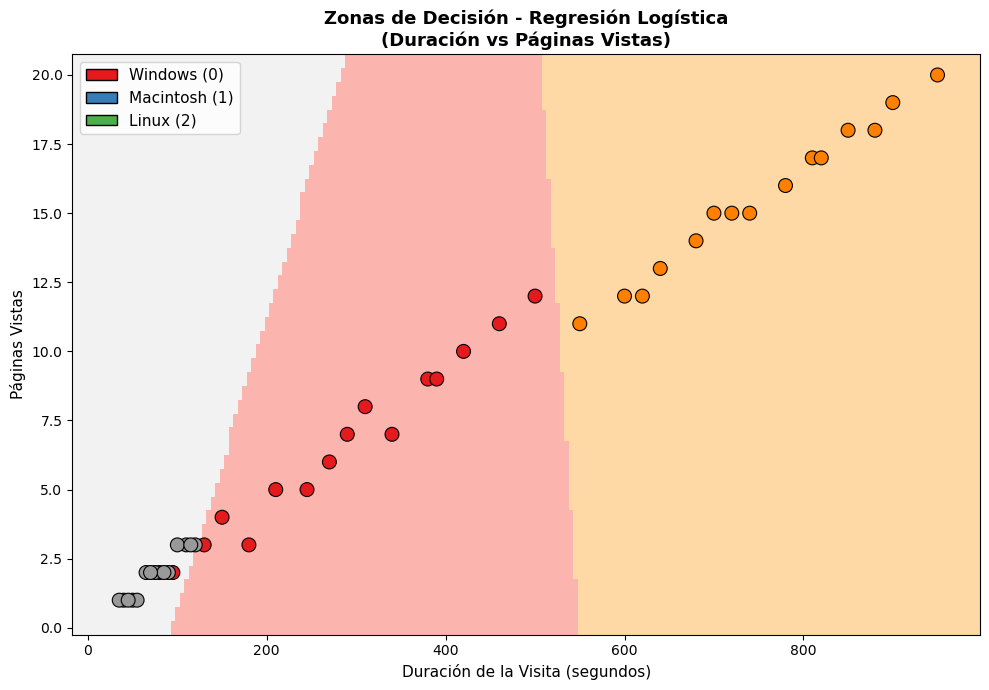

El fondo de color muestra qué SO predice el modelo para cada zona del gráfico.


In [15]:
# Entrenamos un modelo auxiliar solo con 2 características para poder graficar
X_2d = df[['duracion_segundos', 'paginas_vistas']].values
Y_2d = df['sistema_operativo'].values

clasificador_2d = LogisticRegression(max_iter=1000, random_state=42)
clasificador_2d.fit(X_2d, Y_2d)

# Definimos el rango del gráfico
x_min, x_max = X_2d[:, 0].min() - 50, X_2d[:, 0].max() + 50
y_min, y_max = X_2d[:, 1].min() - 1,  X_2d[:, 1].max() + 1

# Creamos la malla de puntos
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 5),
    np.arange(y_min, y_max, 0.5)
)

# Predecimos el SO para cada punto de la malla
malla = clasificador_2d.predict(np.c_[xx.ravel(), yy.ravel()])
malla = malla.reshape(xx.shape)

# Graficamos
plt.figure(figsize=(10, 7))
plt.pcolormesh(xx, yy, malla, cmap=plt.cm.Pastel1, shading='auto')

# Puntos reales
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=Y_2d,
                      cmap=plt.cm.Set1, s=100,
                      edgecolors='black', linewidth=0.8)

# Leyenda
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor='#E41A1C', edgecolor='black', label='Windows (0)'),
    Patch(facecolor='#377EB8', edgecolor='black', label='Macintosh (1)'),
    Patch(facecolor='#4DAF4A', edgecolor='black', label='Linux (2)'),
]
plt.legend(handles=leyenda, loc='upper left', fontsize=11)

plt.title('Zonas de Decisión - Regresión Logística\n(Duración vs Páginas Vistas)',
          fontsize=13, fontweight='bold')
plt.xlabel('Duración de la Visita (segundos)', fontsize=11)
plt.ylabel('Páginas Vistas', fontsize=11)
plt.tight_layout()
plt.show()

print('El fondo de color muestra qué SO predice el modelo para cada zona del gráfico.')

## Conclusiones

- El modelo de **Regresión Logística** aprendió a distinguir entre los tres sistemas operativos en base al comportamiento del usuario en el sitio web.
- **Windows**: sesiones de duración media, páginas moderadas, acciones intermedias.
- **Macintosh**: sesiones largas, muchas páginas vistas, pocas acciones pero de alto valor.
- **Linux**: sesiones cortas, pocas páginas, pero gran cantidad de acciones rápidas.
- La **zona de decisión** muestra visualmente cómo el modelo separa las regiones del espacio de datos.